예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 `code_reference/README.md` 파일을 참조)

In [1]:

# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트 사용 설정
common.set_korean_plot_env()

다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.

In [2]:

import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 4-2 파이토치로 데이터를 다루는 표준 절차

본 노트북은 본문 4-2절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- 파이토치 데이터셋(`Dataset`)의 정의와 사용
- 의존성 주입 패턴으로 데이터 변환 객체 주입
- `random_split()`으로 훈련, 검증, 평가 데이터셋 분리
- 데이터로더(`DataLoader`)의 생성과 사용
- 데이터로더를 사용하는 미니배치 학습

3장에서 사용한 회오리 데이터(모델 4)를 파이토치의 표준 데이터 파이프라인으로 다시 다룬다.

## 파이토치 데이터셋 정의

- `Dataset`을 상속한 파생 클래스로 정의하며, 두 메서드를 구현한다.
    - `__len__()`: 데이터셋 전체 샘플의 수를 반환한다.
    - `__getitem__(idx)`: `idx`번 샘플을 반환하며, 데이터셋의 동작 방식과 직결되므로 반드시 구현해야 한다.
- 생성자 메서드는 필수가 아니지만, 두 메서드가 실행될 때마다 반복할 준비 작업을 미리 처리하는 용도라 사실상 필수나 다름없다.
- 여기서는 CSV 파일을 불러오는 과정을 생성자에 두고, 두 메서드는 준비된 리스트를 사용한다.

In [3]:
######################################################################################
# 코드 4-7 - 회오리 모양 데이터셋의 정의
######################################################################################

import torch
from torch.utils.data import Dataset
import csv

# 3-3절 회오리 모양 데이터를 사용해 정의한 파이토치 데이터셋 클래스
class SpiralDataset(Dataset):
    # CSV 형식 파일에서 데이터를 불러와 리스트에 저장
    def __init__(self, csv_path):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))

    # 필수 오버라이딩 메서드 1: 데이터셋의 전체 샘플 개수를 반환
    def __len__(self):
        return len(self.X_list)

    # 필수 오버라이딩 메서드 2: 인덱스 idx에 해당하는 데이터 샘플을 반환
    def __getitem__(self, idx):
        x = torch.tensor(self.X_list[idx])
        y = torch.tensor(self.Y_list[idx], dtype=torch.long)
        return x, y

- 정의한 데이터셋은 다음과 같이 사용한다.
    - `len()` 함수로 전체 샘플 수를 확인한다.
    - 인덱싱으로 지정한 순서의 샘플을 꺼낸다.

In [4]:
######################################################################################
# 코드 4-8 - 데이터셋의 사용법
######################################################################################

# 데이터셋 객체 생성
csv_path = '../../data/ch3_spiral_data.csv'         # 데이터 파일의 경로
spiral_dataset = SpiralDataset(csv_path)            # 데이터셋 객체

# 데이터셋 객체 사용
print(f'전체 샘플의 수: {len(spiral_dataset)}')     # 내장 함수 len(): __len__() 메서드 연결
print(f'첫 번째 샘플: {spiral_dataset[0]}')         # 인덱싱: __getitem__() 메서드 연결
print(f'마지막 샘플 3개:\n{spiral_dataset[-3:]}')   #  __getitem__()에 범위 정보가 전달

전체 샘플의 수: 900
첫 번째 샘플: (tensor([ 0.2178, -0.0858]), tensor(0))
마지막 샘플 3개:
(tensor([[-0.8599, -0.1290],
        [-0.3069,  0.3311],
        [ 0.2302, -0.2517]]), tensor([2, 1, 0]))


- 본문에서 깃허브 예제 노트북을 참조하라고 안내한, 메서드별 역할을 조정한 데이터셋 클래스다.
    - 크기가 작고 단순한 데이터라면 생성자 단계에서 텐서 변환까지 마쳐 두고,
    - `__getitem__()` 메서드는 인덱싱으로 샘플을 선택하는 일만 맡는 편이 효율적일 수 있다.
    - 결과는 [코드 4-7]과 같다.

In [5]:
# 참고 - 결과는 같지만 메서드별 역할을 조정한 SpiralDataset 클래스

# 생성자 메서드에서 텐서 변환을 해 두고, __getitem__() 메서드는 인덱싱 후 반환
class SpiralDataset(Dataset):
    def __init__(self, csv_path):
        X_list, Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                X_list.append([float(row['x1']), float(row['x2'])])
                Y_list.append(int(row['label']))
        self.X = torch.tensor(X_list)
        self.Y = torch.tensor(Y_list, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

## 데이터 변환 객체의 주입

- 파이토치 데이터셋은 데이터 변환에 **의존성 주입** 패턴을 주로 사용한다.
    - 여러 벌의 데이터셋 클래스를 만드는 대신, 필요한 데이터 변환 객체를 여러 개 만들어 두고 상황에 맞는 것을 골라 주입한다.
- 데이터 변환 **함수**가 아니라 **객체**라고 부르는 이유는 함수 외에 람다식이나 `__call__()` 메서드를 구현한 클래스의 인스턴스도 흔히 쓰이기 때문이다.

In [6]:
######################################################################################
# 코드 4-9 - 비트별 텐서로 변환하는 데이터 변환 객체
######################################################################################

# 함수로 만든 32 비트 텐서 변환 객체
def to_32bit_tensor(x, y):
    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor(y, dtype=torch.int32)
    return x, y

# 클래스 인스턴스로 만든 64 비트 텐서 변환 객체
class To64BitTensor:
    def __call__(self, x, y):
        x = torch.tensor(x, dtype=torch.double)
        y = torch.tensor(y, dtype=torch.int64)
        return x, y
to_64bit_tensor = To64BitTensor()

# 동일한 입력에 대한 두 변환 결과 비교
x_in, y_in = [0.1, 0.2], 1
print('32 비트 변환:', to_32bit_tensor(x_in, y_in))
print('64 비트 변환:', to_64bit_tensor(x_in, y_in))

32 비트 변환: (tensor([0.1000, 0.2000]), tensor(1, dtype=torch.int32))
64 비트 변환: (tensor([0.1000, 0.2000], dtype=torch.float64), tensor(1))


- 데이터 변환 객체는 데이터셋 생성자의 인자로 전달해 주입한다.
    - 클래스 정의를 바꾸지 않고도 상황에 맞는 변환을 적용할 수 있다.

In [7]:
######################################################################################
# 코드 4-10 - 데이터 변환 객체의 주입
######################################################################################

class SpiralDataset(Dataset):
    # 생성자의 인자로 주입하며, 주입되지 않을 가능성도 고려해 기본값을 지정
    def __init__(self, csv_path, transform=None):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))
        self.transform = transform              # 속성으로 저장

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        x = self.X_list[idx]
        y = self.Y_list[idx]
        # 속성으로 정의해 둔 데이터 변환 객체를 함수처럼 사용해 데이터 변환
        if self.transform is not None:
            x, y = self.transform(x, y)
        return x, y

# 32비트 변환 객체와 64비트 변환 객체 각각을 주입해 데이터셋 객체 생성
spiral_dataset_32 = SpiralDataset(csv_path, to_32bit_tensor)
spiral_dataset_64 = SpiralDataset(csv_path, to_64bit_tensor)

print(spiral_dataset_32[0])     # 32 비트 텐서(torch.float32, torch.int32) 튜플
print(spiral_dataset_64[0])     # 64 비트 텐서(torch.float64, torch.int64) 튜플

(tensor([ 0.2178, -0.0858]), tensor(0, dtype=torch.int32))
(tensor([ 0.2178, -0.0858], dtype=torch.float64), tensor(0))


- 이후 예제에서 사용할 기본 자료형 데이터셋을 다시 만든다.

In [8]:
# 참고 - 학습용 기본 자료형 데이터셋 다시 생성

class SpiralDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.X_list, self.Y_list = [], []
        with open(csv_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                self.X_list.append([float(row['x1']), float(row['x2'])])
                self.Y_list.append(int(row['label']))
        self.transform = transform

    def __len__(self):
        return len(self.X_list)

    def __getitem__(self, idx):
        if self.transform is None:
            x = torch.tensor(self.X_list[idx])
            y = torch.tensor(self.Y_list[idx], dtype=torch.long)
        else:
            x, y = self.transform(self.X_list[idx], self.Y_list[idx])
        return x, y


spiral_dataset = SpiralDataset(csv_path)
print(f'전체 샘플 수: {len(spiral_dataset)}')

전체 샘플 수: 900


## 데이터셋 분리와 데이터로더

- 데이터를 용도별로 나눌 때는 골고루 섞은 뒤 나누는 것이 일반적이다.
    - 순서가 정렬된 상태로 나누면 묶음별 분포가 달라져 검증과 평가가 제대로 이루어지지 않는다.
- `torch.utils.data.random_split()` 함수는 원본 데이터셋과 묶음별 샘플 수의 리스트를 인자로 받는다.
    - 시드값을 고정한 난수 발생기를 `generator` 인자로 전달하면 분할 결과를 재현할 수 있다.

In [9]:
######################################################################################
# 코드 4-11 - 데이터셋의 순서를 무작위로 섞어 훈련, 검증, 평가 데이터셋 분리
######################################################################################

from torch.utils.data import random_split

SEED = 42                                               # 난수 발생 시드값
sample_size = len(spiral_dataset)                       # 전체 데이터셋 샘플 수
train_ratio, valid_ratio, test_ratio = 0.6, 0.2, 0.2    # 구분 비율(합쳐서 1)
train_size = int(sample_size * train_ratio)             # 훈련 데이터셋의 샘플 수
valid_size = int(sample_size * valid_ratio)             # 검증 데이터셋의 샘플 수
test_size = sample_size - train_size - valid_size       # 평가 데이터셋의 샘플 수

train_set, valid_set, test_set = random_split(
    spiral_dataset,                                     # 구분 전 데이터셋
    [train_size, valid_size, test_size],                # 용도별 데이터셋의 샘플 수 리스트
    generator=torch.Generator().manual_seed(SEED),      # 난수 발생기 (시드값 고정 목적)
)

print(f'훈련 데이터셋의 샘플 수: {len(train_set)}')     
print(f'검증 데이터셋의 샘플 수: {len(valid_set)}')     
print(f'평가 데이터셋의 샘플 수: {len(test_set)}')

훈련 데이터셋의 샘플 수: 540
검증 데이터셋의 샘플 수: 180
평가 데이터셋의 샘플 수: 180


- 본문 각주에서 소개한 사이킷런의 `train_test_split()` 함수로도 같은 분할을 할 수 있다.
    - 묶음마다 클래스 비율을 유지하는 층화 분할(`stratify`) 등 편의 기능이 풍부하다.

In [10]:
# 참고 - 사이킷런(scikit-learn)의 train_test_split() 함수로 데이터 분할(각주 8)
# 사이킷런은 파이토치와 별개인 전통 머신러닝 라이브러리로, 별도 설치가 필요하다.
#   pip install scikit-learn
# train_test_split() 함수는 데이터를 두 묶음으로 나누며, 다음과 같은 특징이 있다.
#   - stratify 인자: 지정한 정답 목록의 클래스 비율을 나눈 두 묶음 모두에 유지(층화 분할)
#   - random_state 인자: 분할 재현을 위한 시드값 (파이토치 난수 발생기와는 무관)
#   - 파이토치 Dataset이 아니라 리스트/넘파이 배열을 나누는 함수이므로, 여기서는
#     '샘플 인덱스'를 나눈 후 Subset으로 부분 데이터셋을 만든다.
#     (random_split()의 반환값도 같은 Subset 객체다)

from collections import Counter

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

indices = list(range(len(spiral_dataset)))      # 전체 샘플의 인덱스 (0 ~ 899)
labels = spiral_dataset.Y_list                  # 층화 분할의 기준이 되는 정답 목록

# 1차 분할: 전체를 훈련(60%)과 나머지(40%)로 나눈다.
train_idx, rest_idx = train_test_split(
    indices,
    test_size=0.4,          # 두 번째 묶음(검증+평가)의 비율
    stratify=labels,        # 클래스 비율을 유지하며 분할
    random_state=SEED,      # 시드값 고정 (재현 가능한 분할)
)
# 2차 분할: 나머지(40%)를 검증(20%)과 평가(20%)로 절반씩 나눈다.
# 1차에서 나뉜 묶음의 정답 목록을 stratify에 다시 지정해야 한다.
rest_labels = [labels[i] for i in rest_idx]
valid_idx, test_idx = train_test_split(
    rest_idx,
    test_size=0.5,
    stratify=rest_labels,
    random_state=SEED,
)

# 나눈 인덱스 목록으로 부분 데이터셋(Subset) 구성
train_set_sk = Subset(spiral_dataset, train_idx)
valid_set_sk = Subset(spiral_dataset, valid_idx)
test_set_sk = Subset(spiral_dataset, test_idx)
print(f'훈련/검증/평가 샘플 수: {len(train_set_sk)}/{len(valid_set_sk)}/{len(test_set_sk)}')

# 층화 분할의 효과: 모든 부분 데이터셋에서 클래스 비율(0:1:2 = 1:1:1)이 그대로 유지된다.
for name, idx in (('훈련', train_idx), ('검증', valid_idx), ('평가', test_idx)):
    dist = Counter(labels[i] for i in idx)
    print(f'{name} 데이터셋의 클래스 분포: {dict(sorted(dist.items()))}')

# 비교: [코드 4-11]의 random_split()은 클래스 비율을 보장하지 않는다.
random_split_dist = Counter(labels[i] for i in valid_set.indices)
print(f'random_split() 검증 데이터셋의 클래스 분포: {dict(sorted(random_split_dist.items()))}')

훈련/검증/평가 샘플 수: 540/180/180
훈련 데이터셋의 클래스 분포: {0: 180, 1: 180, 2: 180}
검증 데이터셋의 클래스 분포: {0: 60, 1: 60, 2: 60}
평가 데이터셋의 클래스 분포: {0: 60, 1: 60, 2: 60}
random_split() 검증 데이터셋의 클래스 분포: {0: 47, 1: 71, 2: 62}


- 데이터로더는 `DataLoader` 클래스로 만든다.
    - 파생 클래스를 만들어 쓰는 `Dataset`과 달리, 필요한 인자를 지정해 인스턴스를 만들어 사용한다.
    - `batch_size`: 한 번 손실을 계산하고 파라미터를 최적화할 때 사용하는 샘플의 개수
    - `shuffle`: `True`로 지정하면 데이터셋의 샘플을 무작위 순서로 사용

In [11]:
######################################################################################
# 코드 4-12 - 훈련, 검증, 평가 데이터로더 생성
######################################################################################

from torch.utils.data import DataLoader

BATCH_SIZE = 250            # 배치 크기: 하이퍼파라미터로 대문자 변수명 사용

# 훈련 데이터로더: 샘플을 무작위 순서로 섞어서 배치 구성
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)

# 검증과 평가 데이터로더: 데이터셋 샘플 순서대로 배치 구성
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'배치 크기: {BATCH_SIZE}')

배치 크기: 250


- 데이터로더는 반복 가능 객체이므로 `for` 루프와 함께 사용한다.
    - 배치 크기만큼의 샘플이 담긴 배치 텐서가 루프 변수에 할당된다.
    - 데이터셋의 `__getitem__()`이 반환하는 값의 개수만큼 배치 텐서가 만들어지므로, 그 개수만큼 루프 변수를 지정해 나눠 받거나 하나의 변수로 리스트를 받는다.
    - 필요한 만큼만 만들어 메모리를 효율적으로 쓰며, 제너레이터와 달리 에포크마다 반복해 사용할 수 있다.

In [12]:
######################################################################################
# 코드 4-13 - for 루프로 데이터로더 사용
######################################################################################

# 데이터셋 __getitem__() 메서드 반환값(입력, 정답)에 대응하는 두 개의 루프 변수 필요
for i, (inputs, labels) in enumerate(train_loader):
    print(f'{i+1}번째 배치: {len(inputs)}개의 샘플')
# 마지막 배치는 남은 샘플(40개)로만 구성함

1번째 배치: 250개의 샘플
2번째 배치: 250개의 샘플
3번째 배치: 40개의 샘플


## 데이터로더를 사용하는 미니배치 학습

- 본문 [코드 4-14]에는 배치 학습 함수, 검증 함수, 조기 종료 적용 코드가 생략되어 있다.
- 본문 안내대로 완성된 학습 함수를 아래에 싣는다. 연습 삼아 직접 구현한 뒤 비교해 보기를 권한다.
- 에포크별 손실은 각 미니배치로 계산한 손실의 평균값을 사용한다.
    - 데이터셋의 샘플 수가 배치 크기의 배수가 아니면 배치마다 샘플 수가 달라지므로 가중 평균으로 계산한다.

In [13]:
# 참고 - [코드 4-14]의 학습에 필요한 배치별 학습 함수 및 검증 함수

# 배치별로 모델 파라미터를 최적화하는 학습 함수
def train_batch(model, X_train, Y_train, criterion, optimizer):    
    model.train()                                       # 학습 모드
    Y_train_pred = model(X_train)
    train_loss = criterion(Y_train_pred, Y_train)       # 훈련 손실 계산
    optimizer.zero_grad()
    train_loss.backward()                               # 훈련 손실로 역전파
    optimizer.step()
    return train_loss.item()

# 모델 성능을 검증하는 검증 함수
def validate(model, X_valid, Y_valid, criterion):
    model.eval()                                        # 평가 모드
    with torch.no_grad():
        Y_valid_pred = model(X_valid)
        valid_loss = criterion(Y_valid_pred, Y_valid)   # 검증 손실 계산
    return valid_loss.item()

In [14]:
######################################################################################
# 코드 4-14 - 데이터로더를 사용하는 미니배치 학습
######################################################################################

import copy

# 조기 종료 방식으로 모델을 학습하는 학습 함수
#   데이터셋 텐서 대신 데이터로더(train_loader, valid_loader)를 인자로 전달
#   배치별로 학습, 검증을 하며, 매 배치의 크기가 달라질 수 있어 가중 평균으로 손실을 집계
#   본문 수록 코드에 생략된 조기 종료 관련 로직을 포함하고 있음
def train_with_early_stopping(model,
                              train_loader, valid_loader,
                              criterion, optimizer, epochs, patience):
    # 표준 학습 로거 생성
    log = common.EpochLogger(epochs, columns=('훈련 손실', '검증 손실'),
                             formats=('{:.4f}', '{:.4f}'))
    # 조기 종료를 위한 변수 초기화
    best_valid_loss = float('inf')  # 지금까지의 최소 검증 손실: 충분히 큰 값으로 초기화
    best_model_params = None        # 검증 손실이 최소일 때의 파라미터를 저장할 딕셔너리
    patience_counter = 0            # 참을성 카운터
    best_epoch = 0                  # 최적 에포크: 검증 손실이 최소일 때의 에포크

    for epoch in range(1, epochs + 1):
        # 훈련, 검증 손실의 가중합과 훈련, 검증 샘플 수 누적 변수: 에포크마다 초기화
        train_loss_sum, valid_loss_sum = 0, 0
        train_sample_size, valid_sample_size = 0, 0

        # 최적화 단계: train_batch()는 train_epoch()와 같지만 최적화 단위가 배치로 바뀜
        # 미니배치를 반복해 1 에포크 구성
        for X_train, Y_train in train_loader:
            # X_train, Y_train: 미니배치를 구성하는 입력과 정답 텐서
            train_loss = train_batch(model, X_train, Y_train, criterion, optimizer)
            # 각 배치별 가중 평균으로 손실값 계산 (미니배치마다 샘플의 수가 다를 수 있음)
            minibatch_size = X_train.size(0)                   # 미니배치의 샘플 수
            train_sample_size += minibatch_size                # 전체 샘플 수 누적 계산
            train_loss_sum += train_loss * minibatch_size      # 가중합
        train_loss_avg = train_loss_sum / train_sample_size    # 가중 평균

        # 검증 단계: validate()도 검증 단위가 배치로 바뀌며, 가중 평균으로 검증 손실 계산
        for X_valid, Y_valid in valid_loader:
            valid_loss = validate(model, X_valid, Y_valid, criterion)
            minibatch_size = X_valid.size(0)
            valid_sample_size += minibatch_size
            valid_loss_sum += valid_loss * minibatch_size
        valid_loss_avg = valid_loss_sum / valid_sample_size

        # 학습 로그 저장 및 출력
        log.row(epoch, train_loss_avg, valid_loss_avg)

        # 조기 종료 판단
        if valid_loss_avg < best_valid_loss:
            # 최소 검증 손실보다 작은 경우 (현재가 최소 검증 손실)
            best_valid_loss = valid_loss_avg                        # 최소 검증 손실 갱신
            best_model_params = copy.deepcopy(model.state_dict())   # 최소 검증 손실 시점의 파라미터 저장
            best_epoch = epoch                                      # 최소 손실 에포크 갱신
            patience_counter = 0                                    # 참을성 카운터 초기화
        else:
            # 최소 검증 손실이 갱신되지 않은 경우
            patience_counter += 1                                   # 참을성 카운터 1 증가
            if patience_counter >= patience:                        # 한계 초과 시 조기 종료                
                break

    print(f'최적({best_epoch} 에포크/검증 손실 {best_valid_loss:.4f}) 파라미터로 모델 복원')
    model.load_state_dict(best_model_params)
    return log

- 완성한 학습 함수로 회오리 데이터를 실제로 학습하고, 학습 곡선으로 진행 과정을 확인한다.

In [15]:
# 참고 - 위 학습 함수로 회오리 데이터를 실제 학습
from collections import OrderedDict
import torch.nn as nn
import torch.optim as optim

HIDDEN_DIM = 64


class SpiralMLPReLU(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(OrderedDict([
            ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
            ('activation_1', nn.ReLU()),
            ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
            ('activation_2', nn.ReLU()),
            ('output', nn.Linear(HIDDEN_DIM, 3)),
        ]))

    def forward(self, x):
        return self.net(x)


torch.manual_seed(SEED)
model = SpiralMLPReLU()
LR = 0.001
EPOCHS = 1000
PATIENCE = 30
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

log = train_with_early_stopping(
    model, train_loader, valid_loader, criterion, optimizer,
    EPOCHS, PATIENCE
)

   에포크    훈련 손실    검증 손실     시간
   1/1000       1.0984       1.0944     0:00


 100/1000       0.7853       0.7674     0:01


 200/1000       0.4922       0.5124     0:02


 300/1000       0.3200       0.3752     0:03


 400/1000       0.2256       0.2997     0:04


 500/1000       0.1720       0.2720     0:04


 600/1000       0.1406       0.2475     0:05
최적(599 에포크/검증 손실 0.2474) 파라미터로 모델 복원


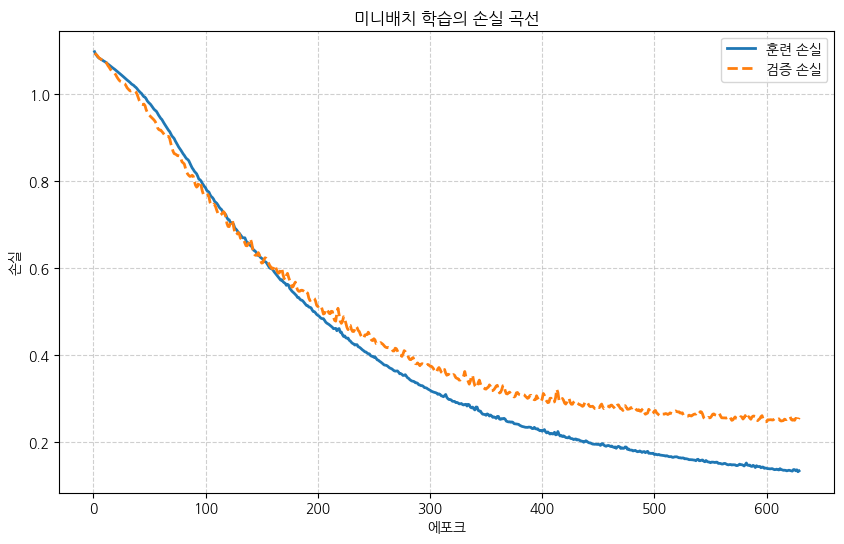

In [16]:
# 참고 - 미니배치 학습 곡선 (EpochLogger 표준)
log.plot(title='미니배치 학습의 손실 곡선', y_label='손실')

- 학습과 검증에 사용하지 않은 평가 데이터셋으로 최종 성능을 확인한다.

In [17]:
# 참고 - 모델 평가
def get_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, Y in data_loader:
            outputs = model(X)
            # torch.argmax() 대신 torch.max()를 사용하여 예측 클래스 인덱스(두 번째 반환값) 추출
            _, predicted = torch.max(outputs.data, 1)
            total += Y.size(0)
            correct += (predicted == Y).sum().item()
    return correct / total

# 사용 예시
accuracy = get_accuracy(model, test_loader)
print(f'테스트 데이터셋 정확도: {accuracy:.4f}')

테스트 데이터셋 정확도: 0.9333


- 데이터셋과 달리 **데이터로더의 `len()` 결과는 샘플 수가 아니라 전체 배치의 개수**다.

In [18]:
# 참고 - 데이터로더의 len() 함수는 미니배치의 개수를 반환

print(f'훈련 미니배치의 개수: {len(train_loader)}개')   
print(f'검증 미니배치의 개수: {len(valid_loader)}개')

훈련 미니배치의 개수: 3개
검증 미니배치의 개수: 1개


## 데이터셋을 합치는 방법

- `random_split()`과 반대로 여러 데이터셋을 하나로 합칠 때는 `torch.utils.data.ConcatDataset` 클래스를 사용한다.
- 본문에서 소개한 K-겹 교차 검증법([연습문제 4-6])처럼 검증 데이터를 교체해 가며 학습할 때 쓰인다.

In [19]:
######################################################################################
# 코드 4-15 - 데이터셋을 합치는 방법
######################################################################################

from torch.utils.data import ConcatDataset

# 합치는 데이터셋은 같은 구조의 샘플을 반환하는 Dataset 객체여야 모델 학습에 사용할 수 있음
combined_dataset = ConcatDataset([train_set, valid_set, test_set])
print(f'합친 데이터셋의 샘플 수: {len(combined_dataset)}')

합친 데이터셋의 샘플 수: 900


## 정리

- 파이토치 데이터셋은 `Dataset`을 상속해 `__len__()`과 `__getitem__()`을 구현한다. 반복되는 준비 작업은 생성자에 두면 효율적이다.
- 데이터 변환은 의존성 주입 패턴으로 처리한다. 변환 객체를 생성자 인자로 전달하면 클래스 정의를 바꾸지 않고 변환을 갈아 끼울 수 있다.
- `random_split()`은 데이터셋을 무작위로 섞어 나누며, `generator` 인자로 분할 결과를 재현할 수 있다.
- 데이터로더는 배치 크기만큼 샘플을 묶어 반복 가능 객체로 제공하고, `len()`은 배치의 개수를 반환한다.
- 미니배치 학습에서 에포크 손실은 배치별 손실의 가중 평균으로 계산한다.

> 학습 결과의 구체적인 수치는 실행 환경에 따라 본문과 조금씩 다를 수 있다.